In [1]:
import numpy as np
import polars as pl
from pathlib import Path

import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 16

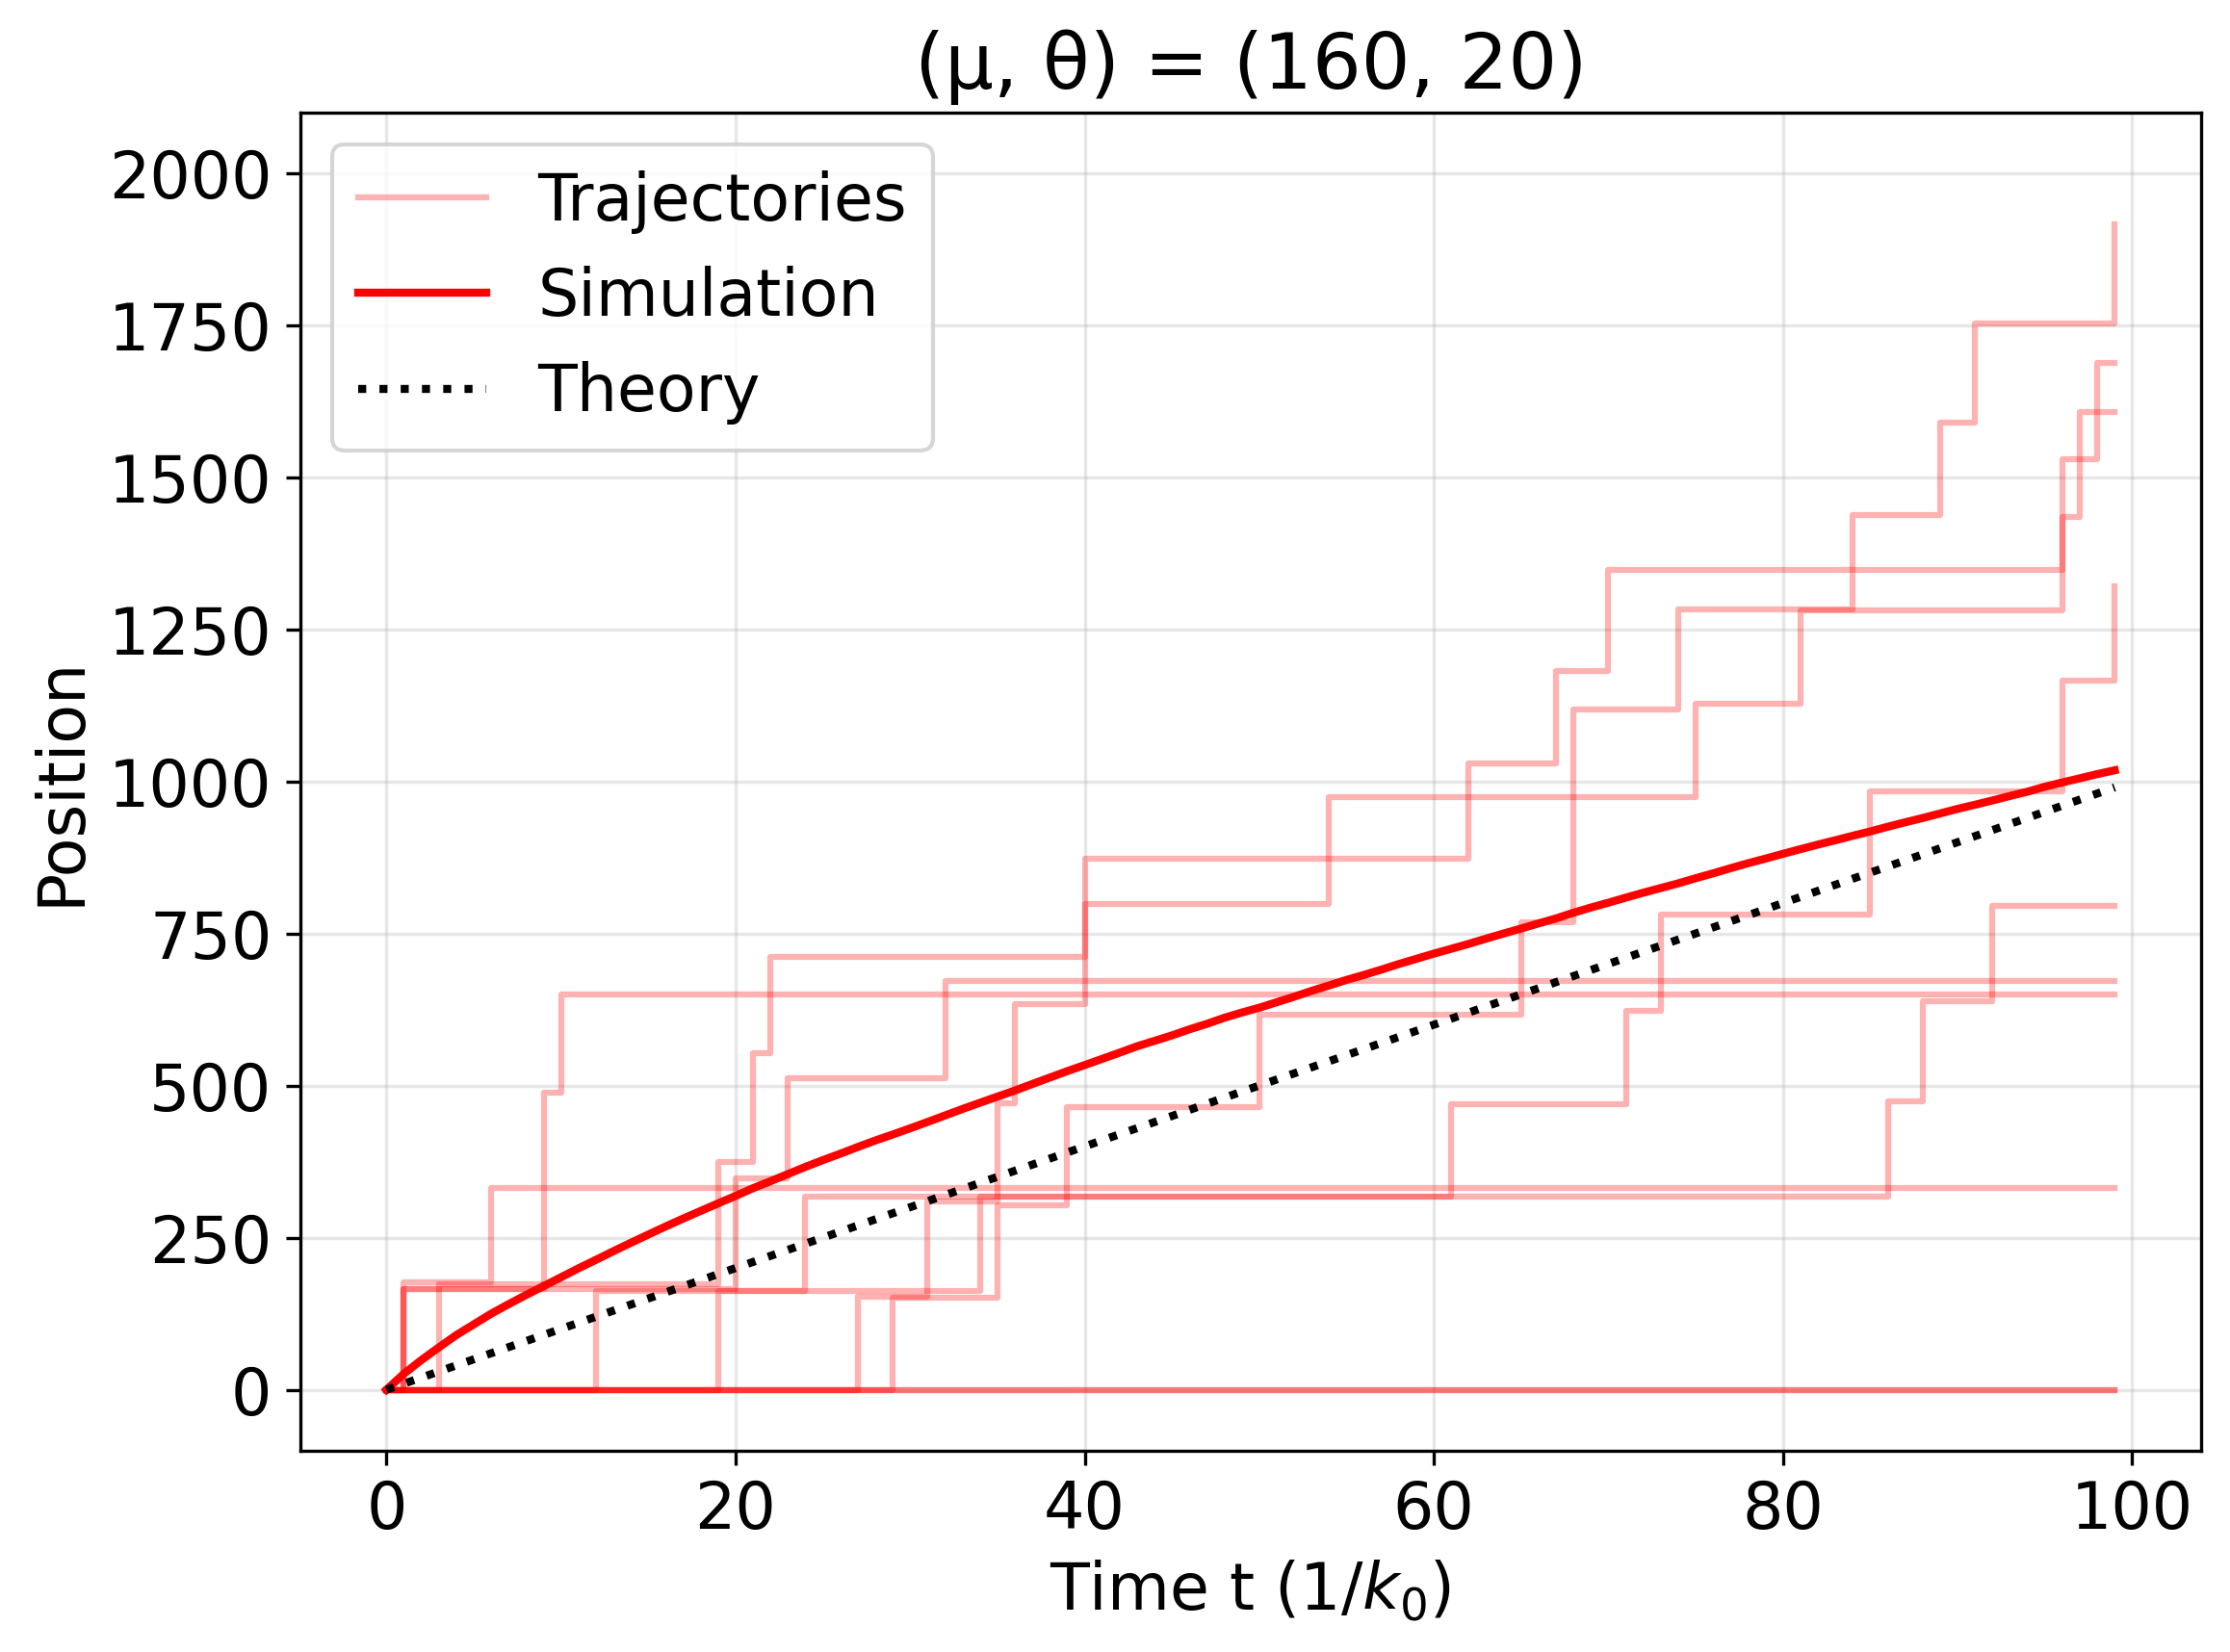

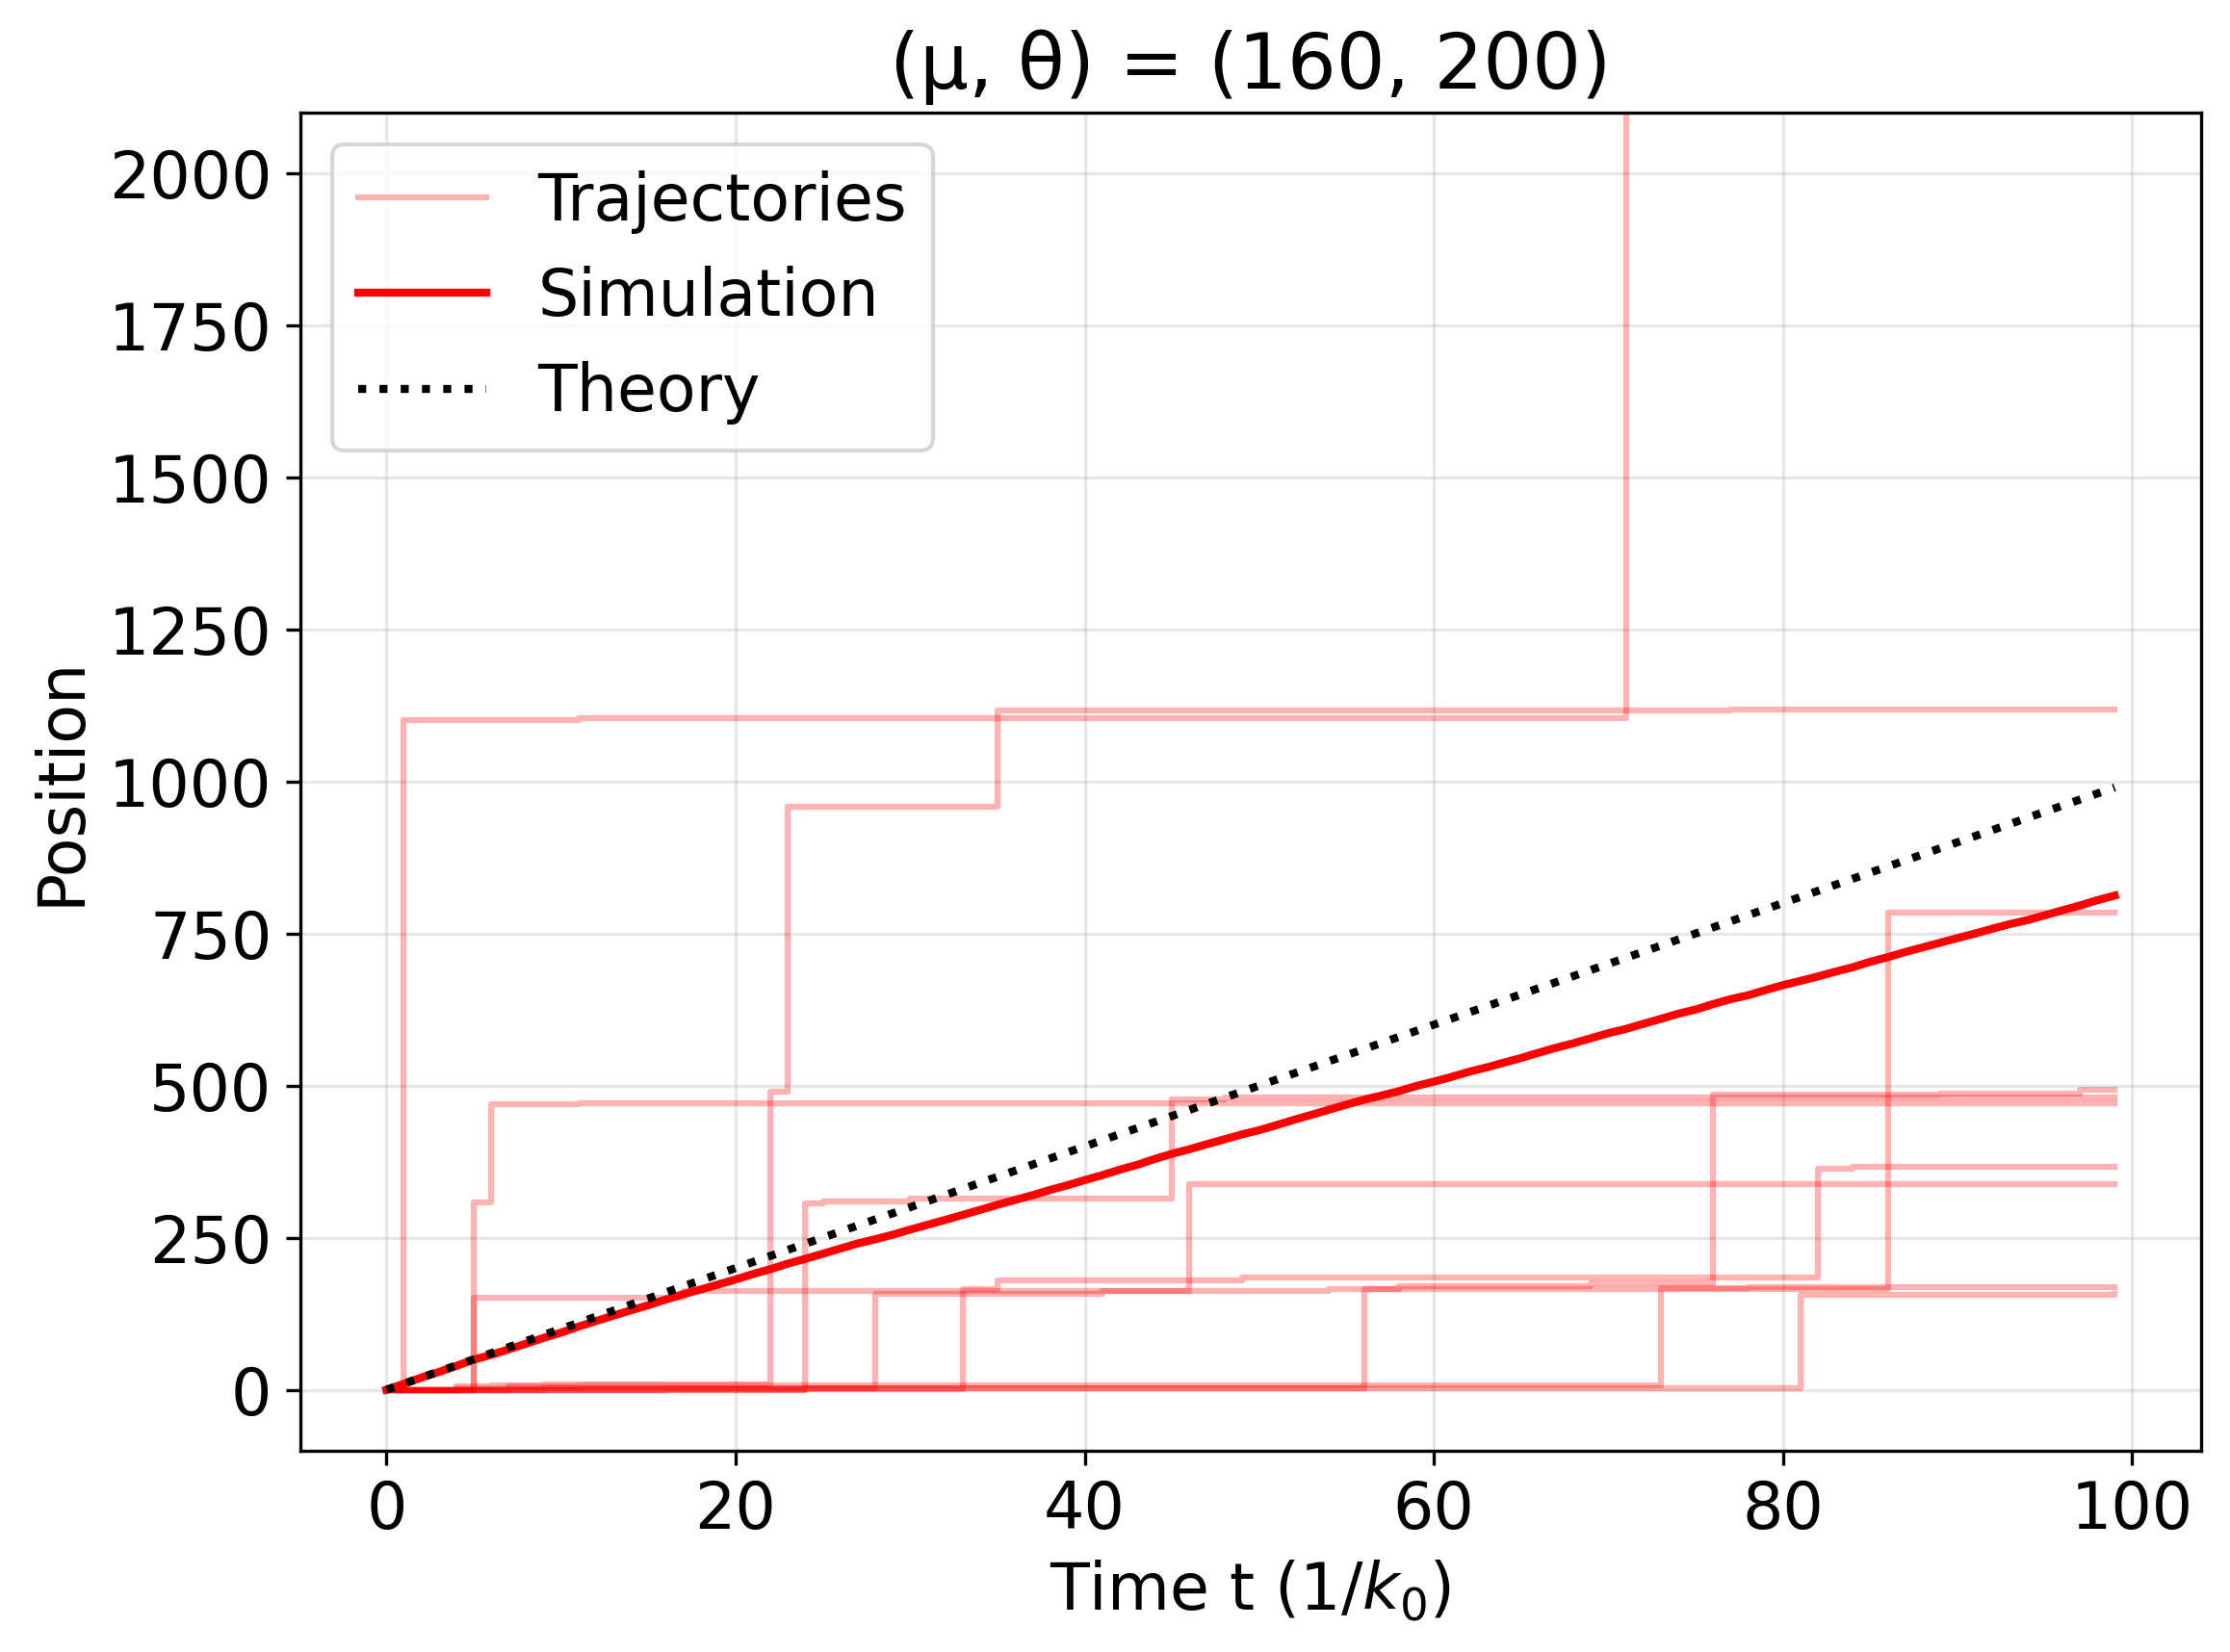

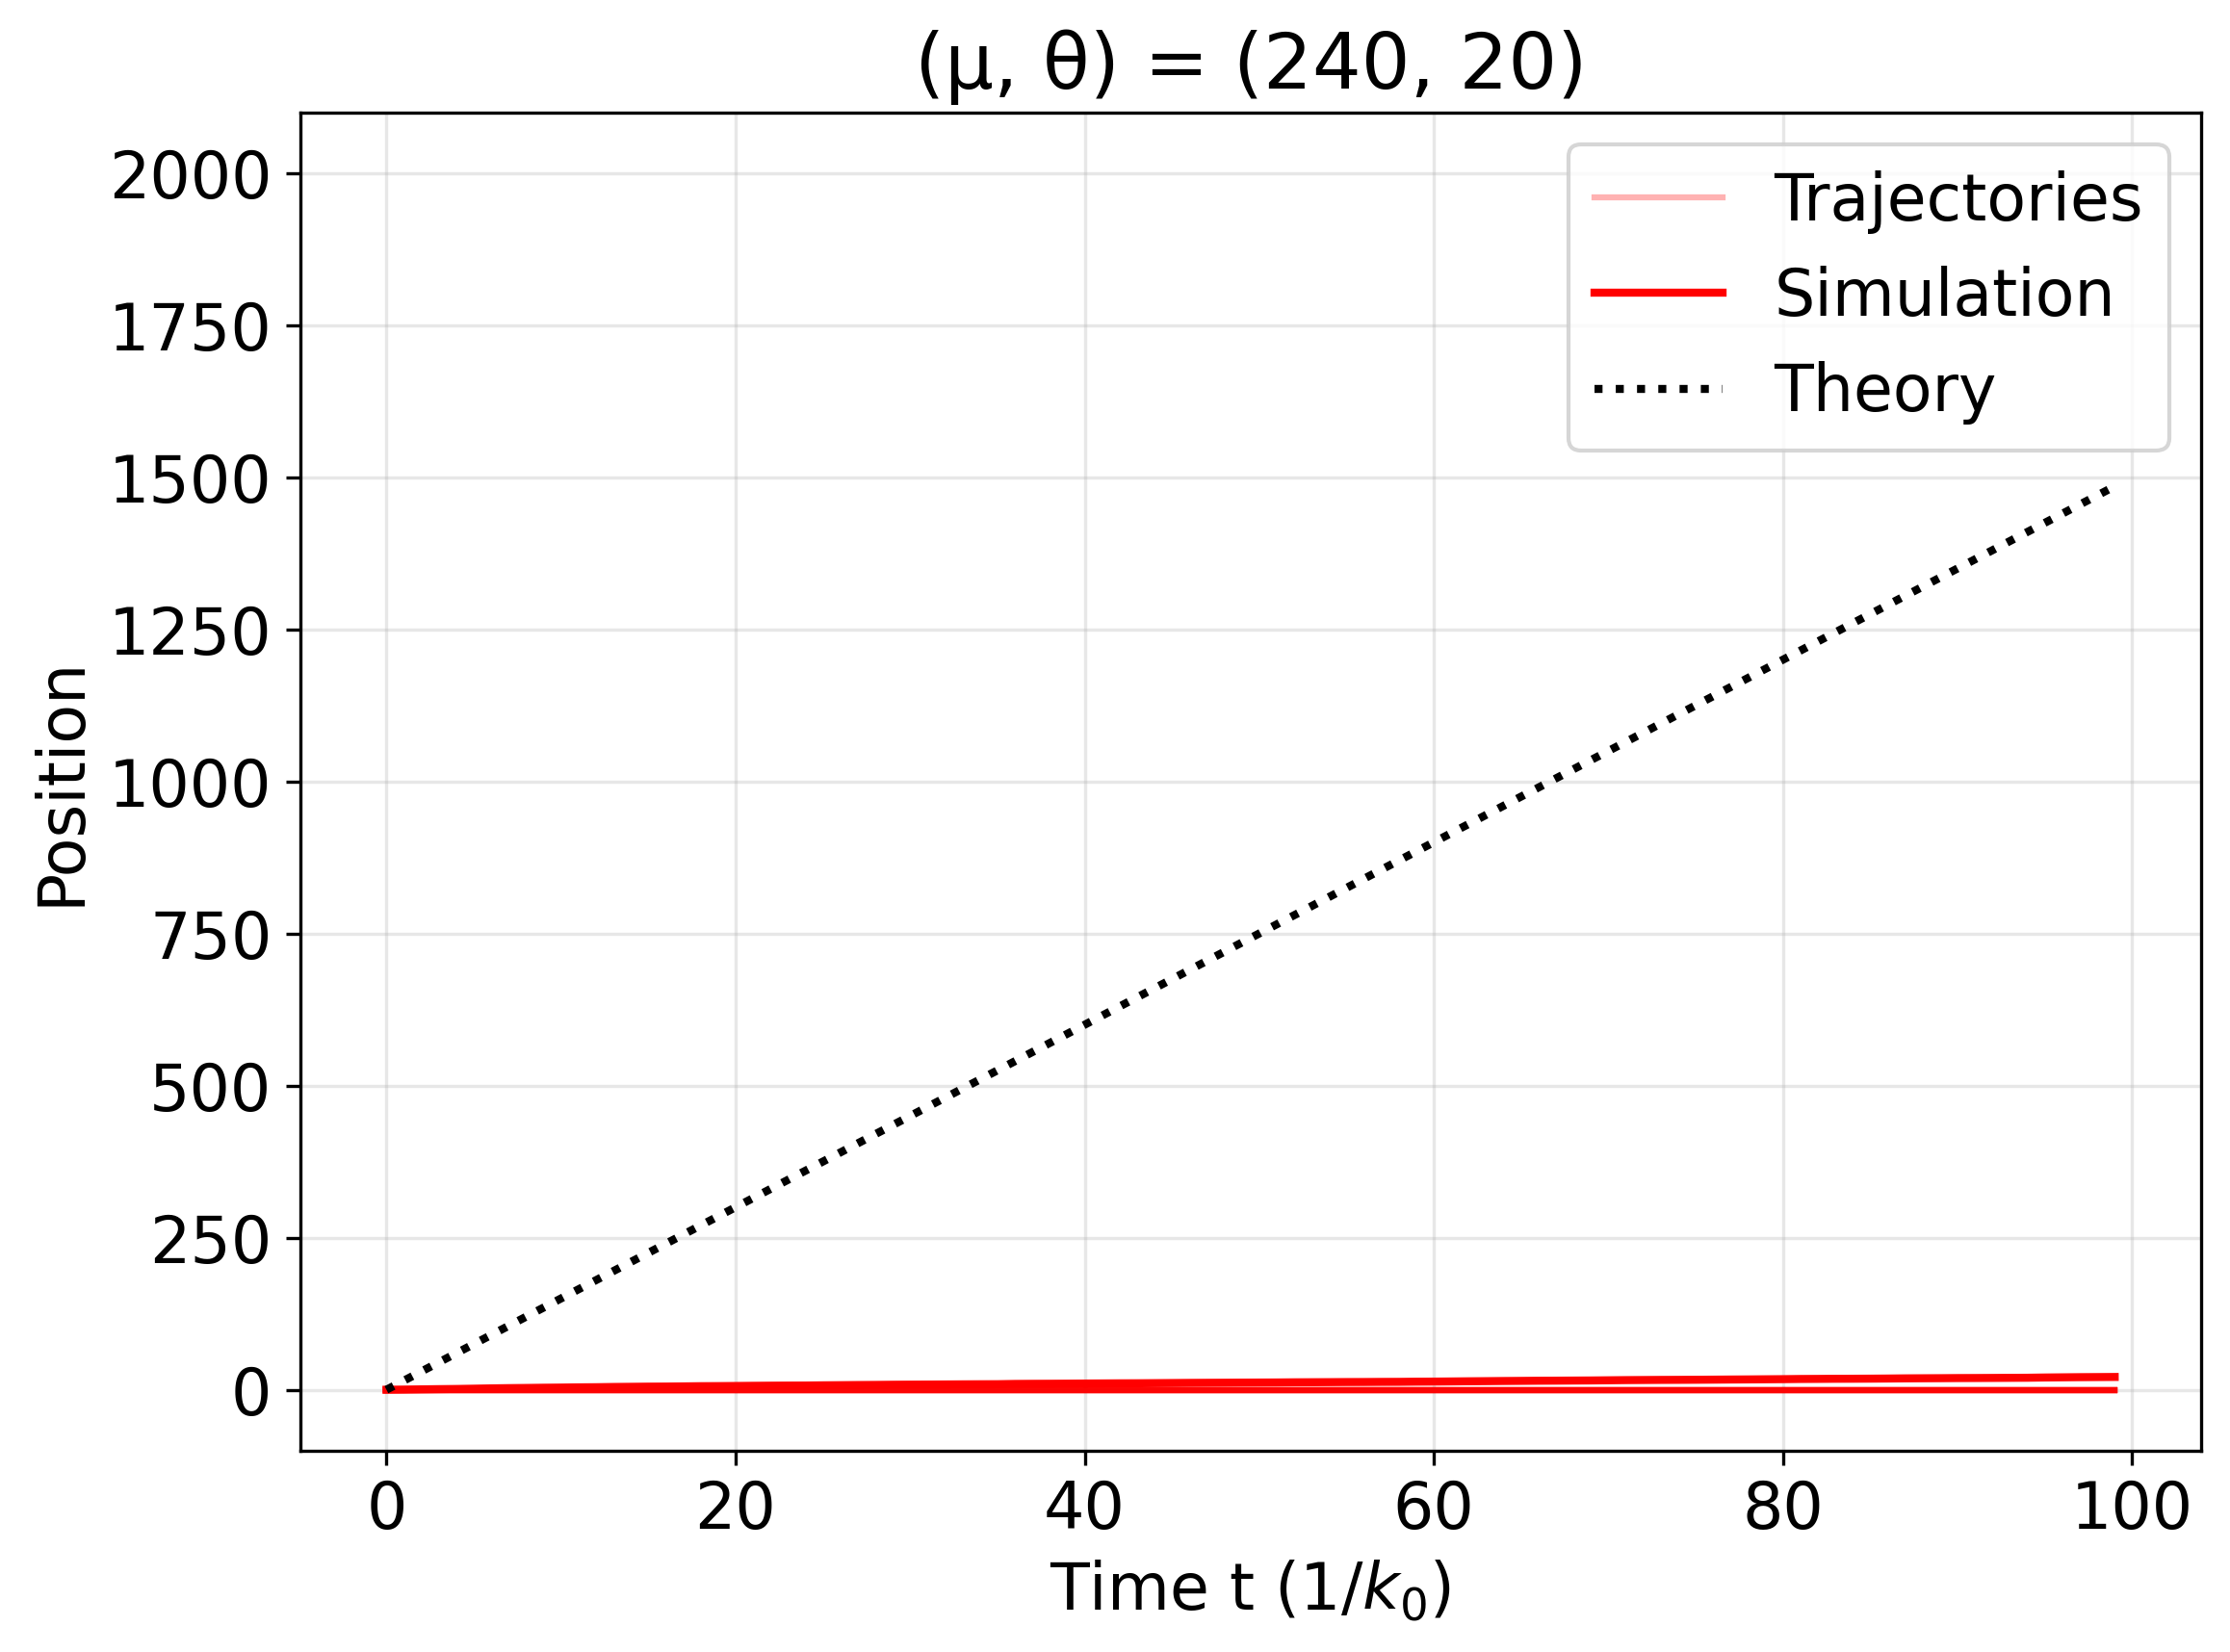

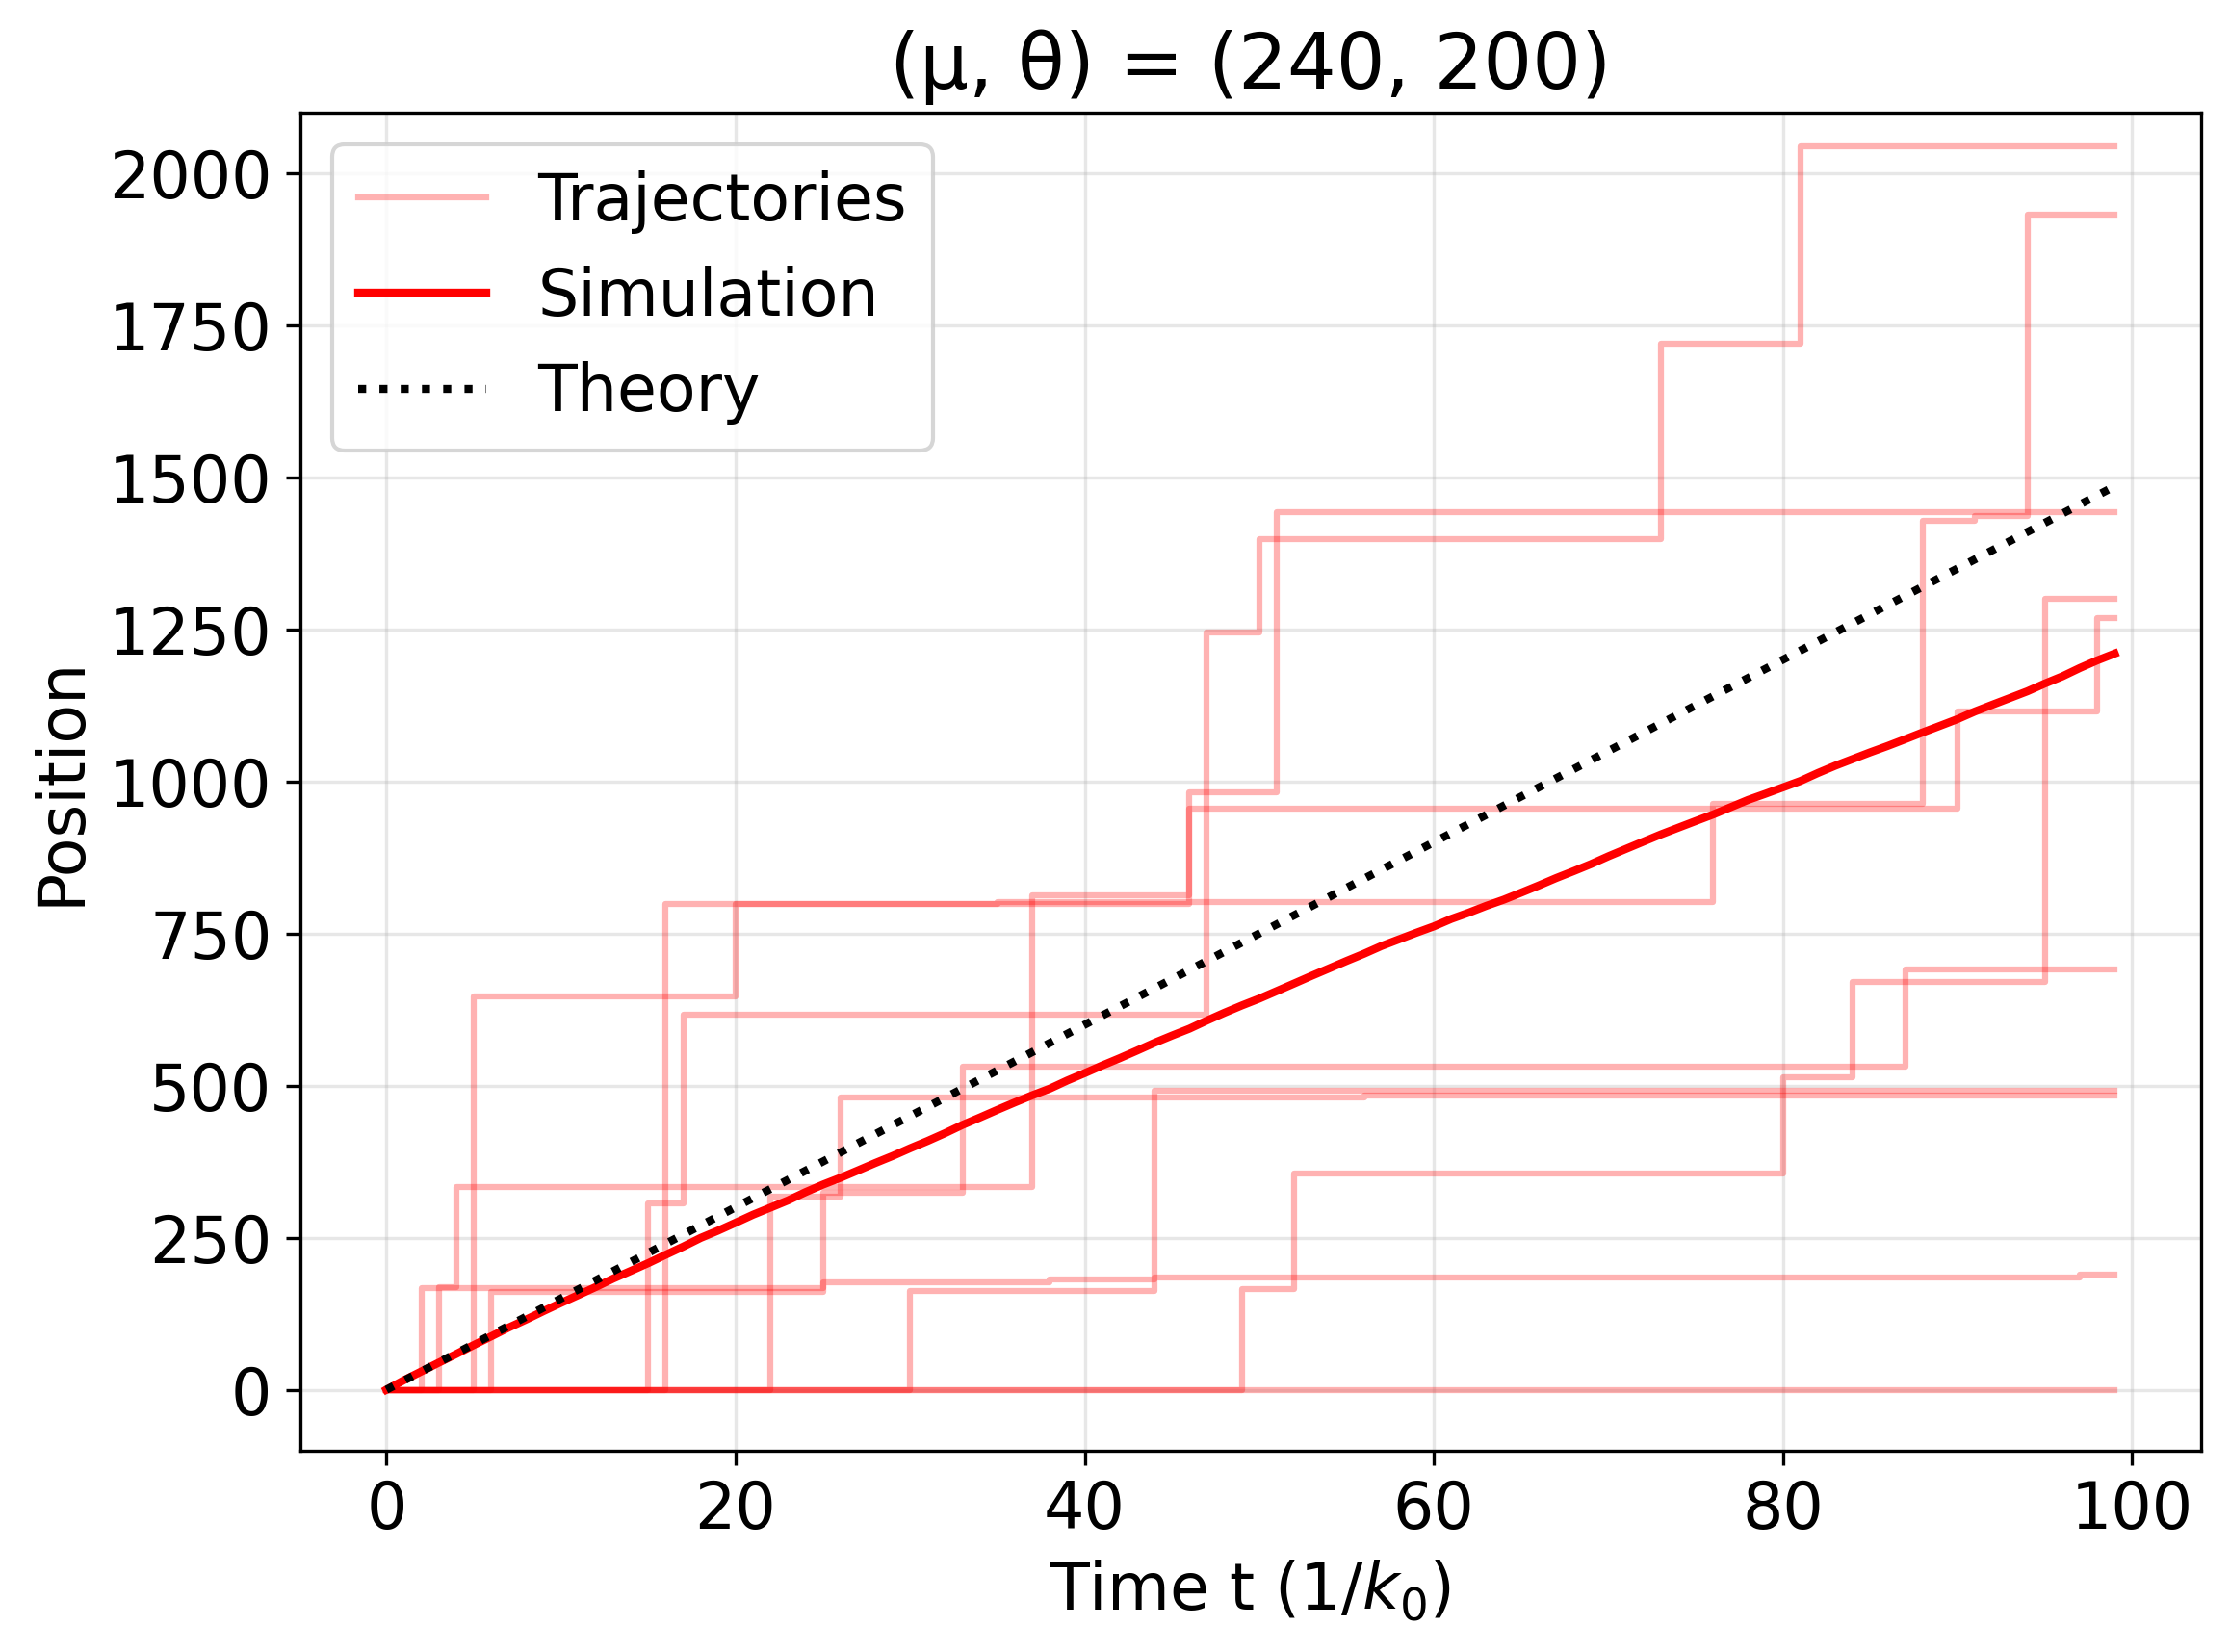

In [3]:
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# --- Load files --- #
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/FIGURES__PC__2026-06-18/nucleo__fig3__0")
paths = sorted(str(p) for p in root.glob("*/**/*.parquet")) or sorted(str(p) for p in root.glob("*/*.parquet"))

df_all = (
    pl.scan_parquet(paths)
    .collect()
    .sort(by=[
        "algo", "fact", "mode",
        "land", "s", "l", "alphac", "alphar"
    ])
)

df_one = df_all.filter(pl.col("land") == "random")

# --- couples uniques --- #
pairs = (
    df_one.select(["mu", "theta"])
    .unique()
    .sort(["mu", "theta"])
    .to_numpy()
)

# --- loop --- #
for mu_val, theta_val in pairs:

    df_theta = df_one.filter(
        (pl.col("mu") == mu_val) &
        (pl.col("theta") == theta_val)
    )

    if df_theta.height == 0:
        continue

    # --- SAFE extraction --- #
    trajs = df_theta["results"][0]          # déjà une list/array
    mean_traj = df_theta["results_mean"][0]
    times = df_theta["times"][0]
    v_mean_th = df_theta["v_mean_th"][0]

    # mu peut être scalar ou array selon ton dataset
    mu = df_theta["mu"][0]

    # --- Plot --- #
    plt.figure(figsize=(8, 6), dpi=300)

    # trajectoires
    n_traj = min(10, len(trajs))
    for i in range(n_traj):
        plt.plot(trajs[i], drawstyle="steps-post",
                 color="red", alpha=0.3,
                 label="Trajectories" if i == 0 else None)

    # moyenne
    plt.plot(mean_traj,
             color="red", lw=2,
             label="Simulation")

    # théorie (IMPORTANT: scalaire attendu)
    plt.plot(times, np.array(times) * v_mean_th,
             color="black", lw=2, ls=":",
             label="Theory")

    plt.ylim([-100, 2100])
    plt.grid(alpha=0.3)
    plt.title(f"(μ, θ) = ({mu}, {theta_val})")
    plt.xlabel(r"Time t ($1/k_0$)")
    plt.ylabel("Position")
    plt.legend()
    plt.tight_layout()
    plt.show()

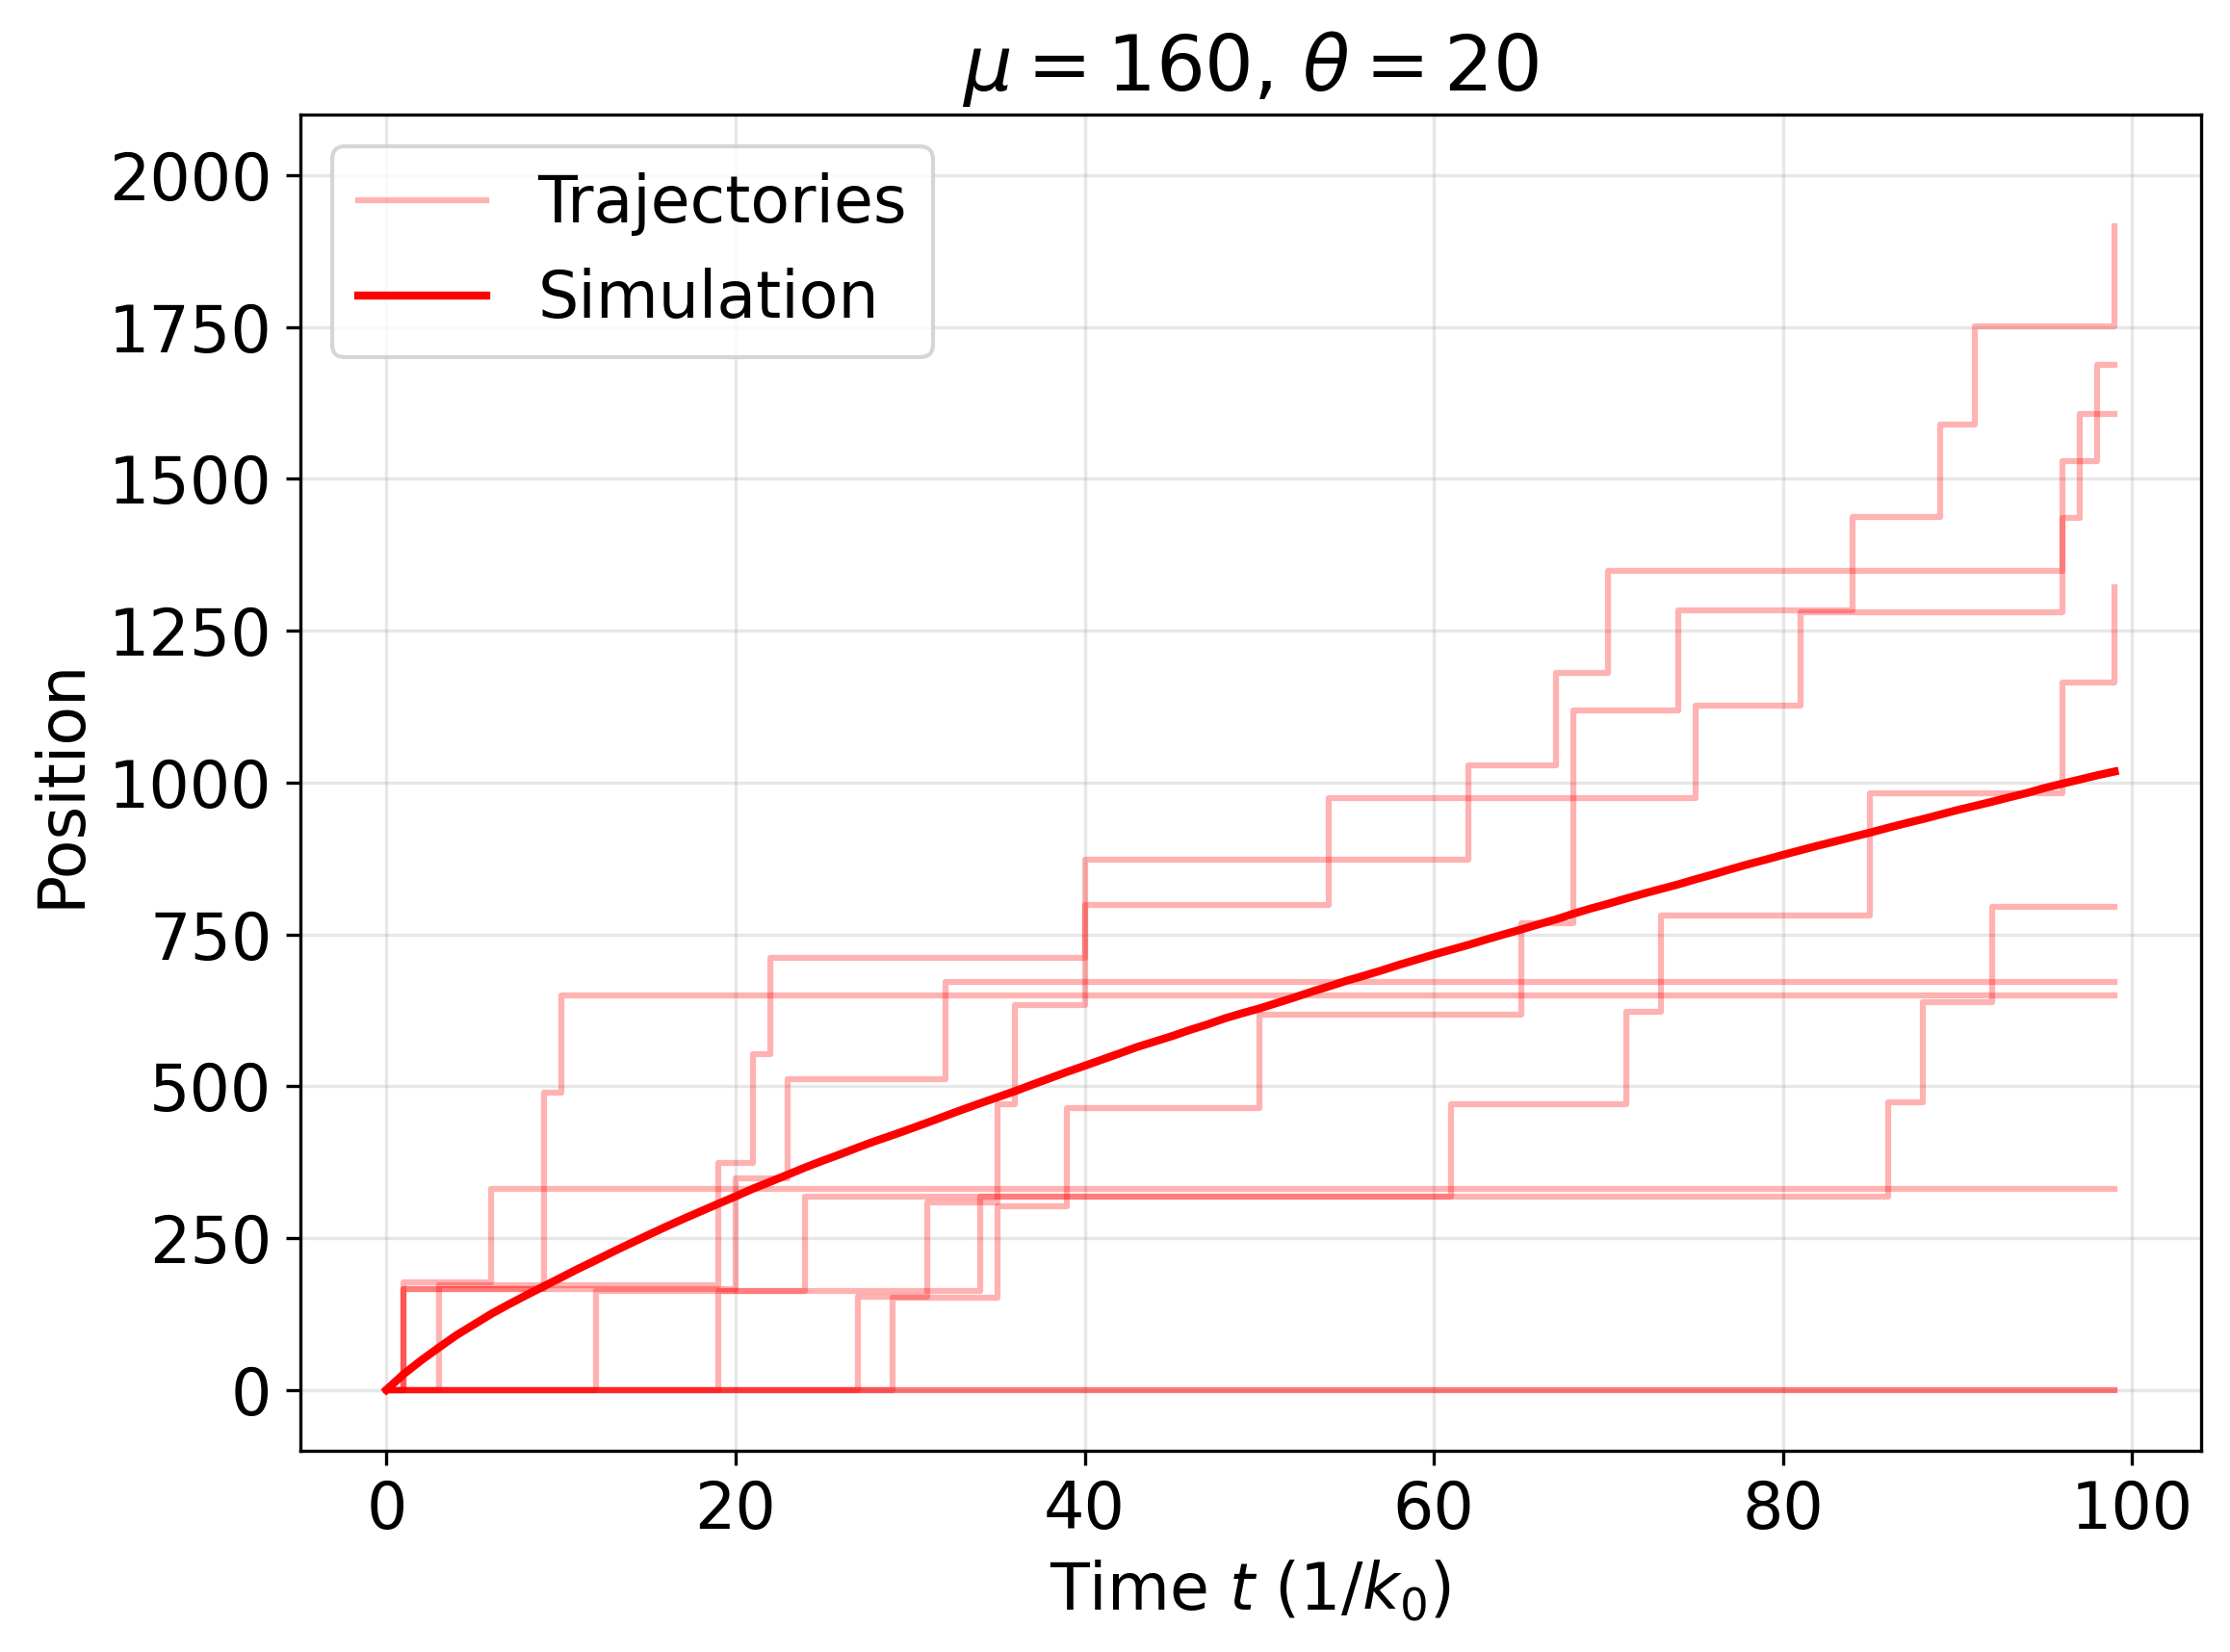

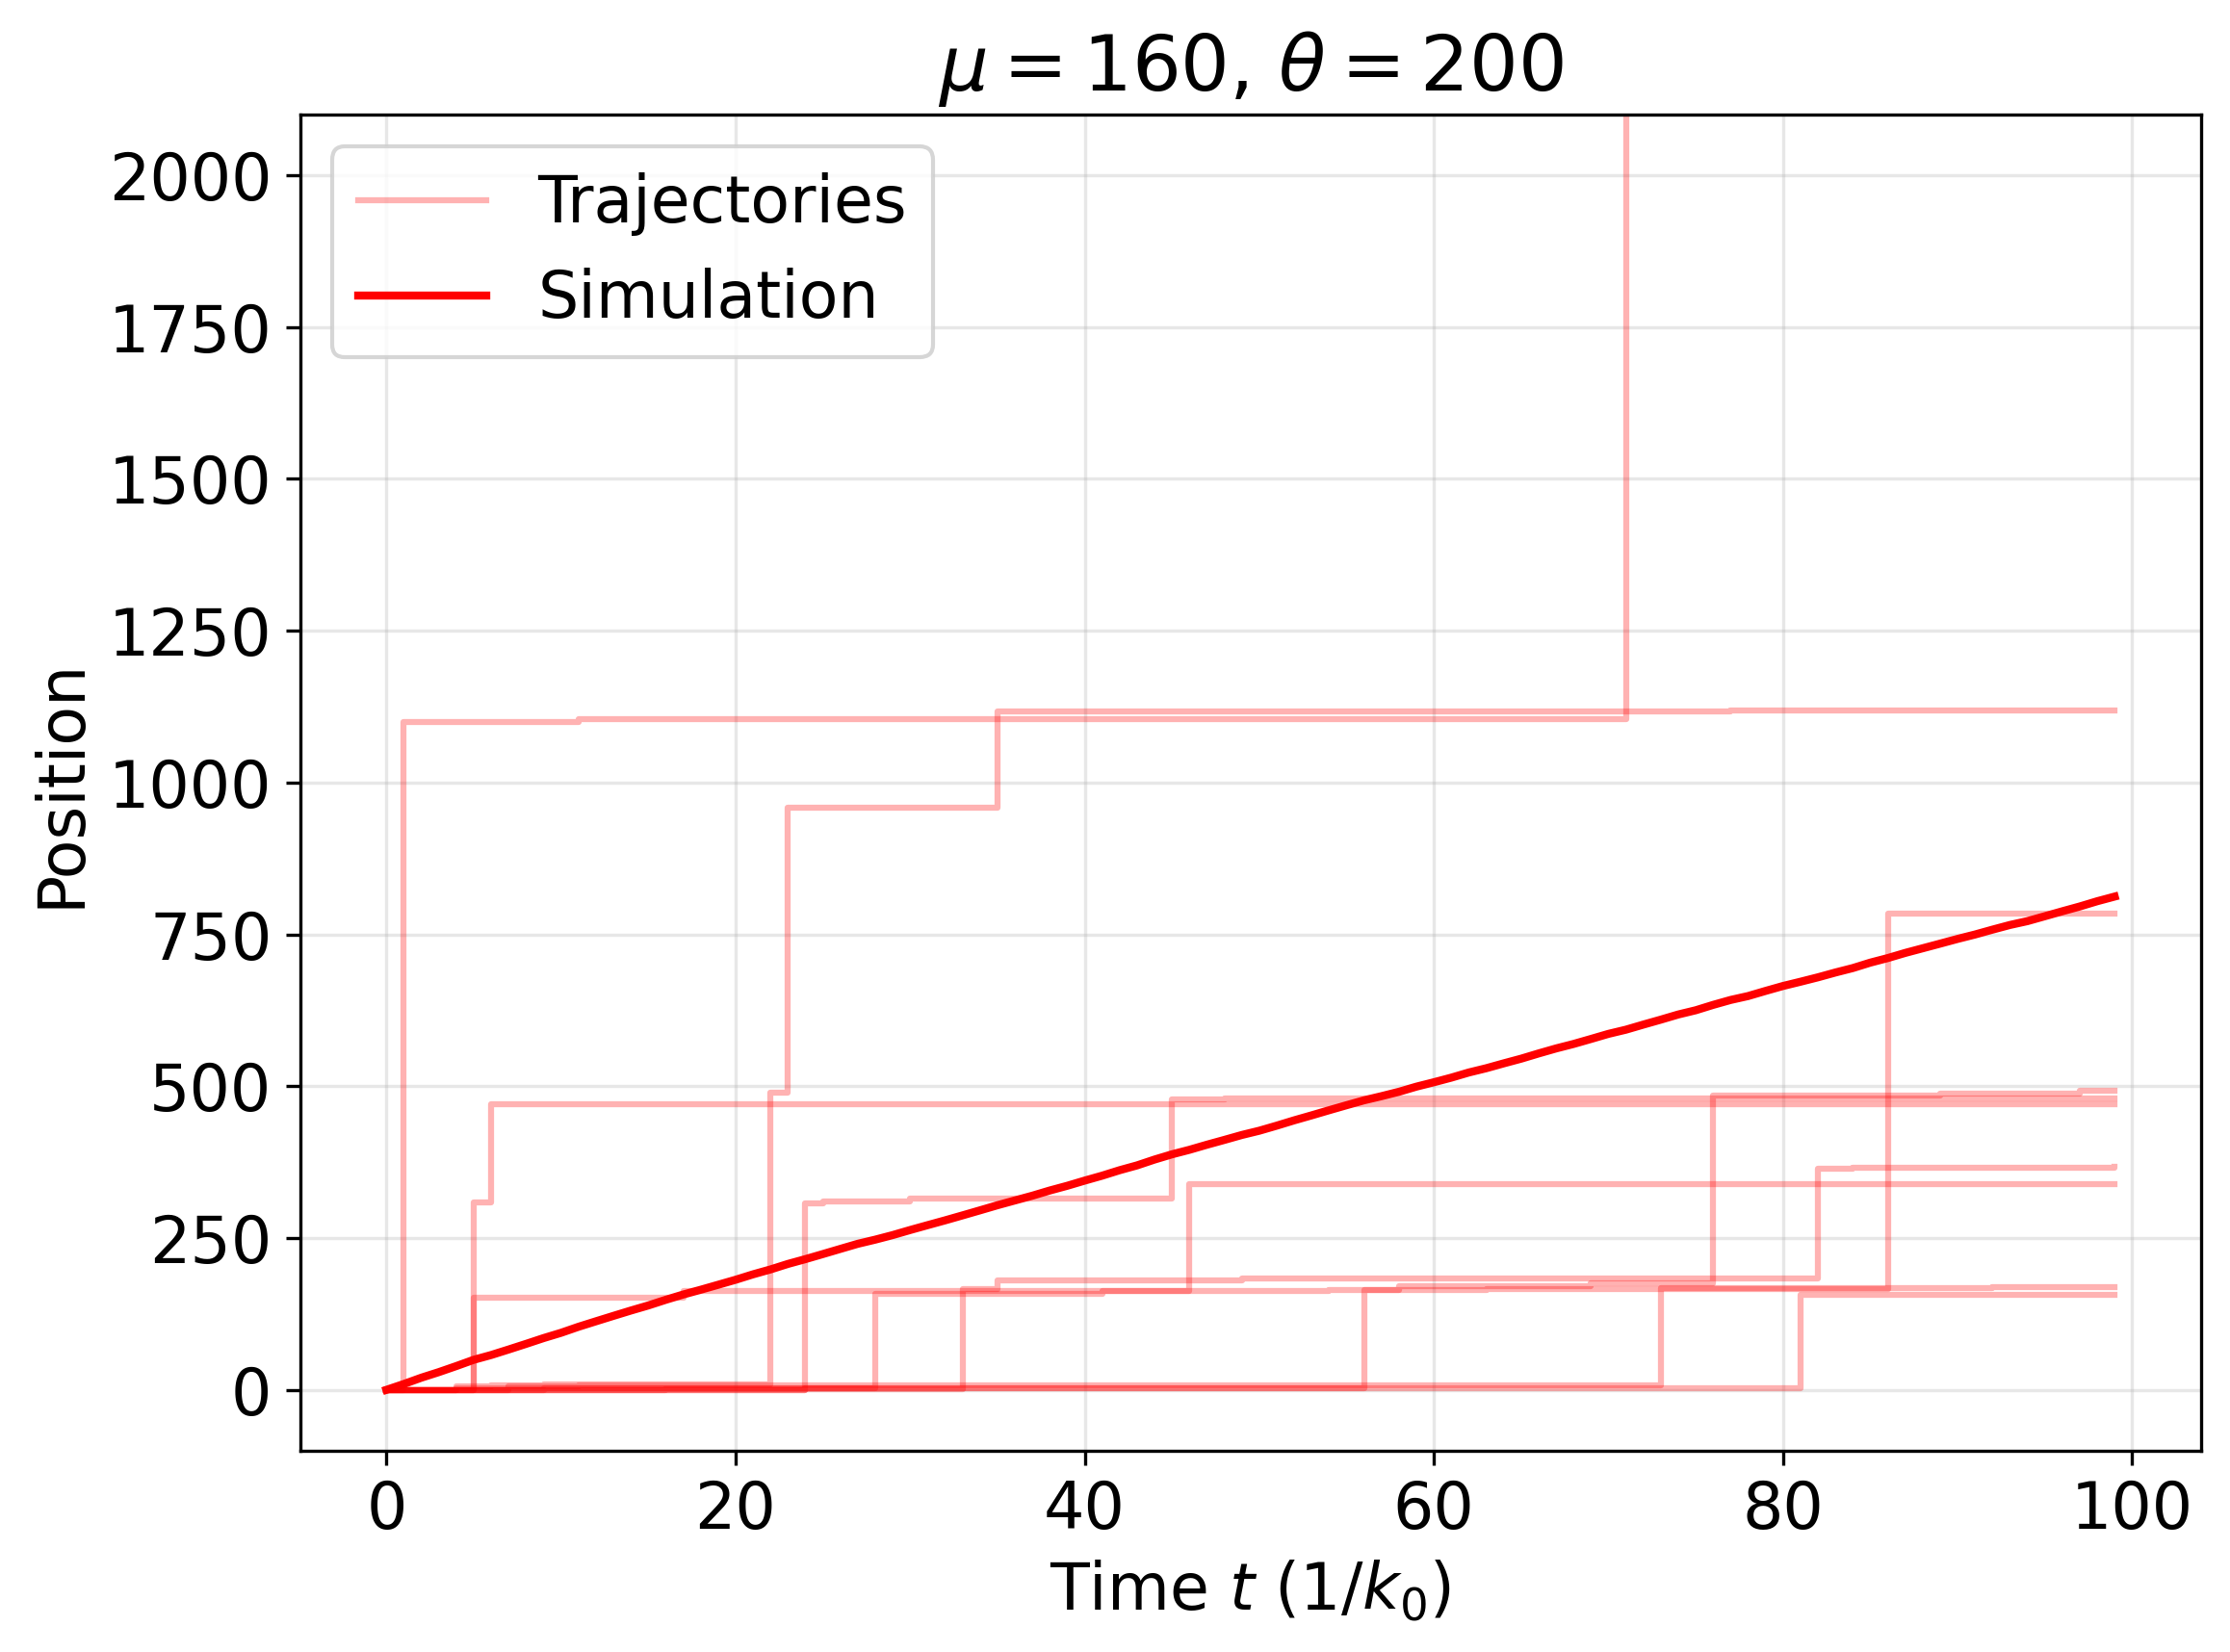

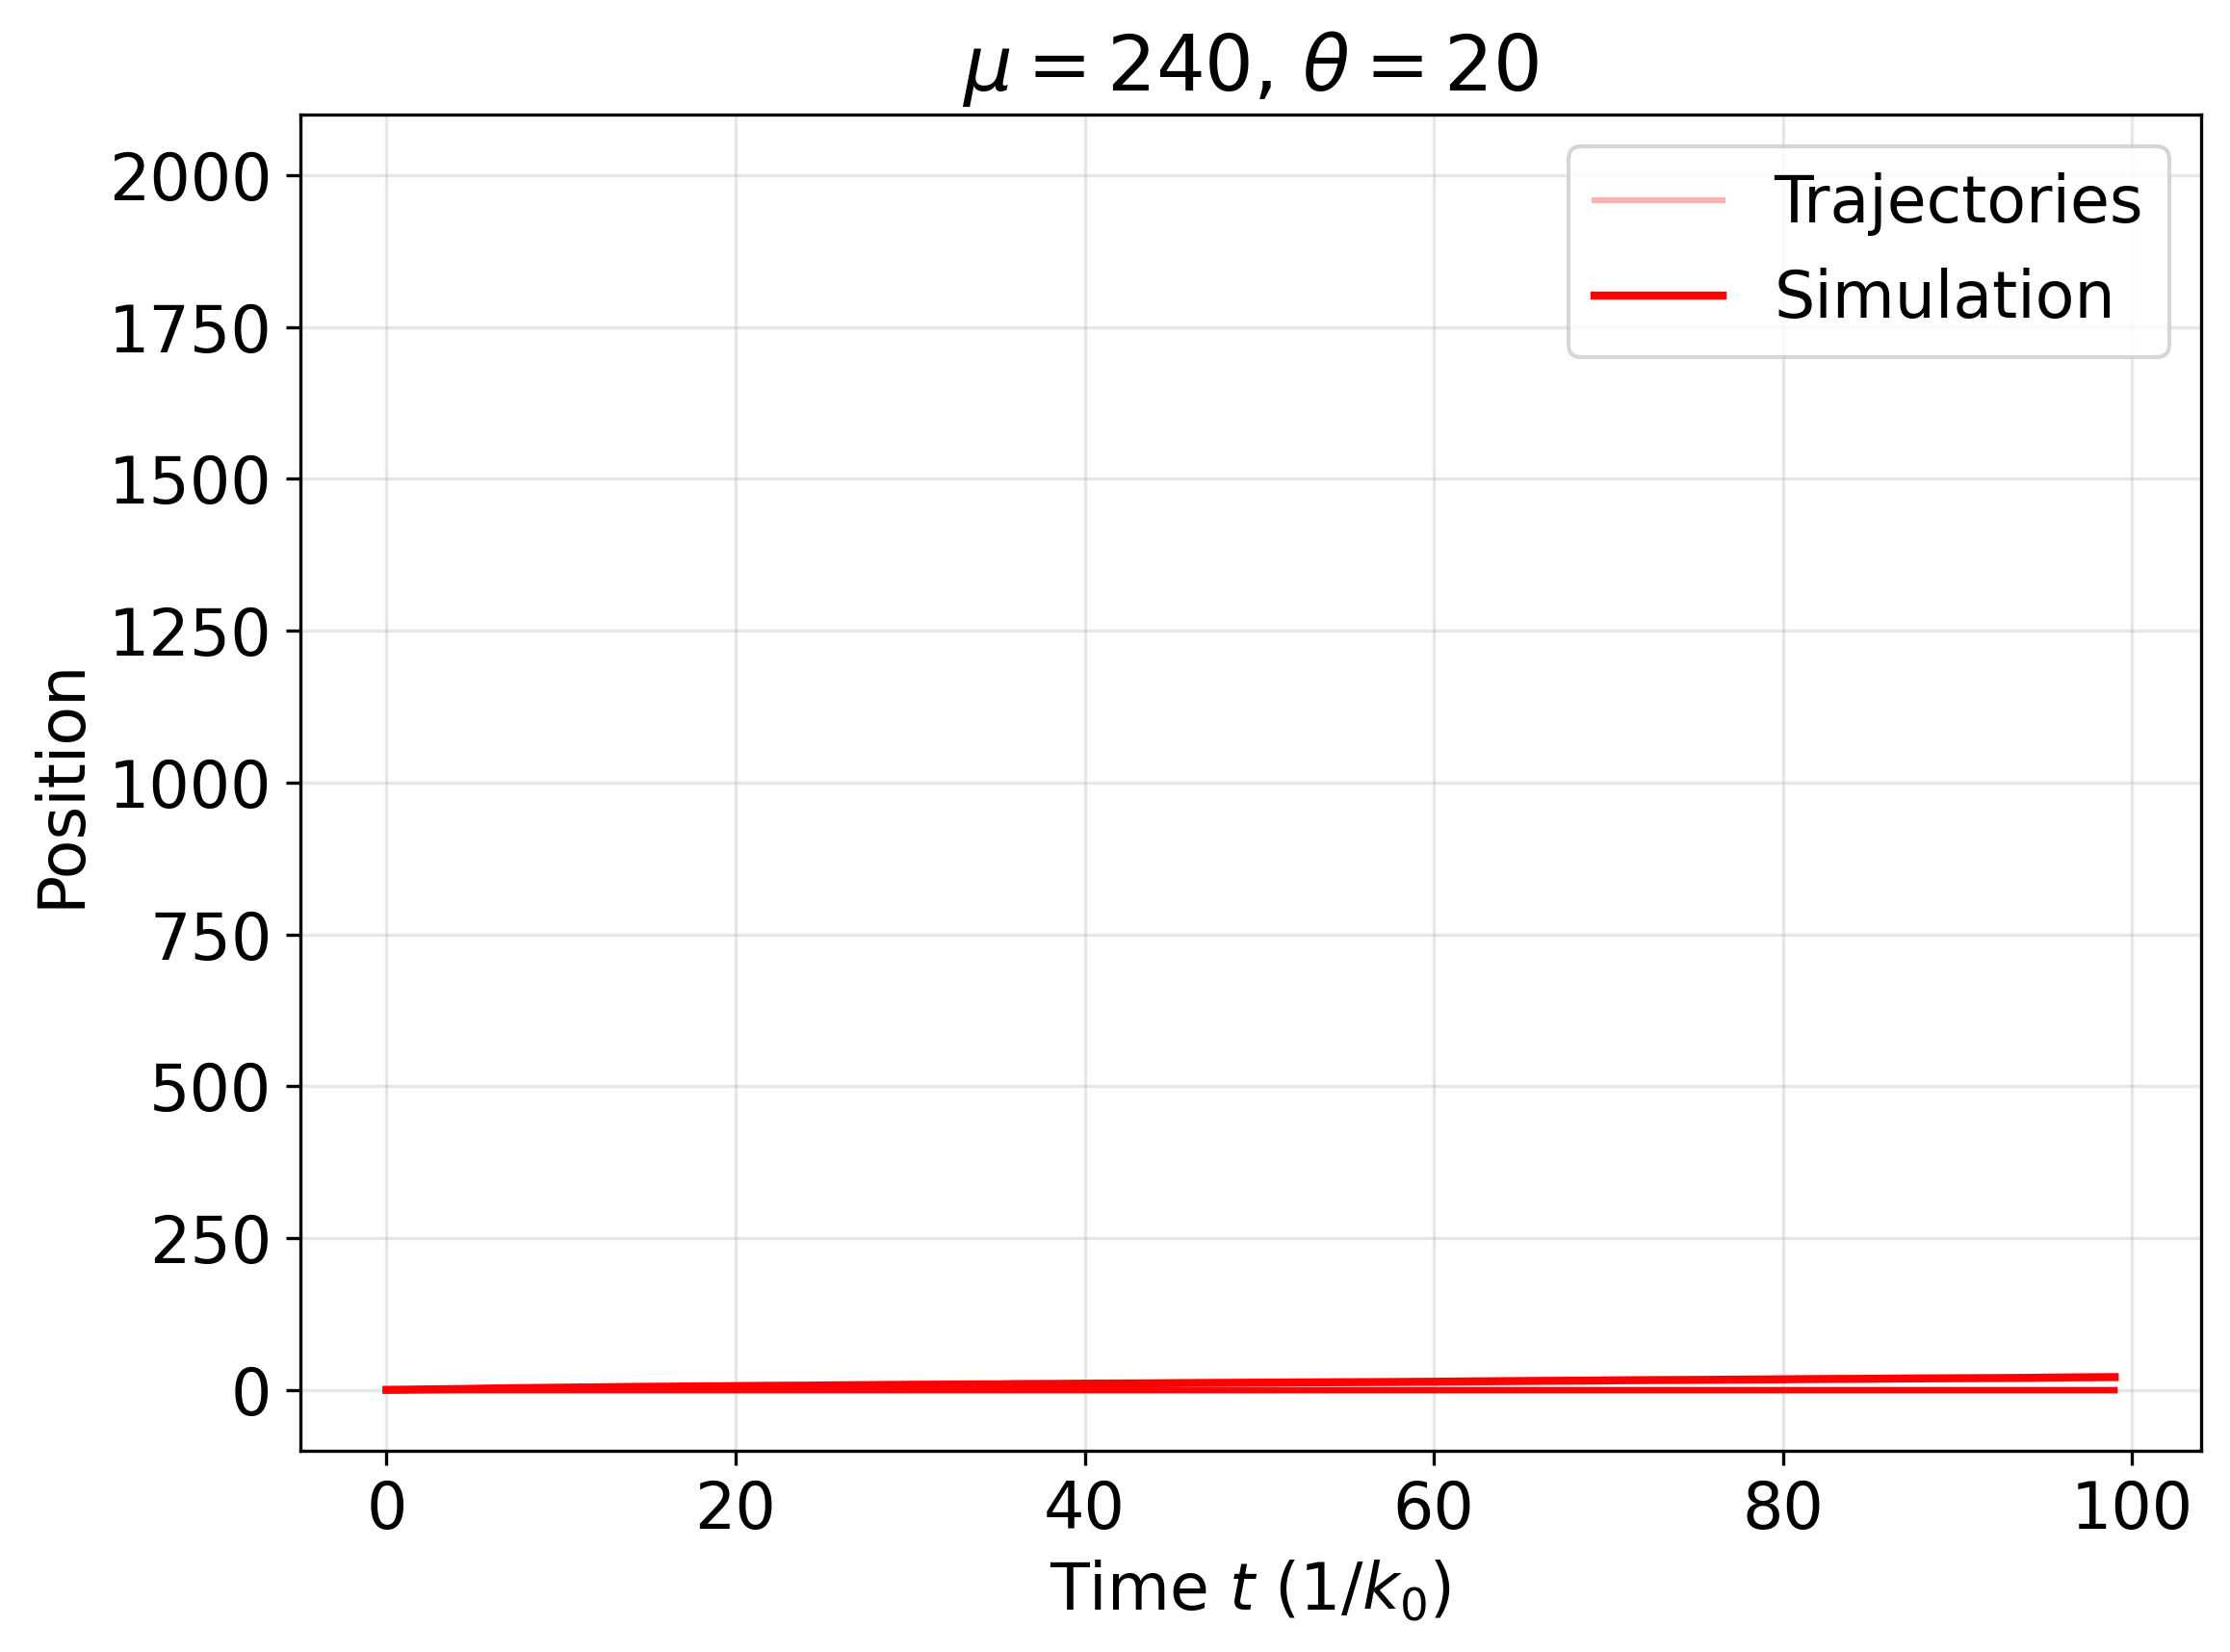

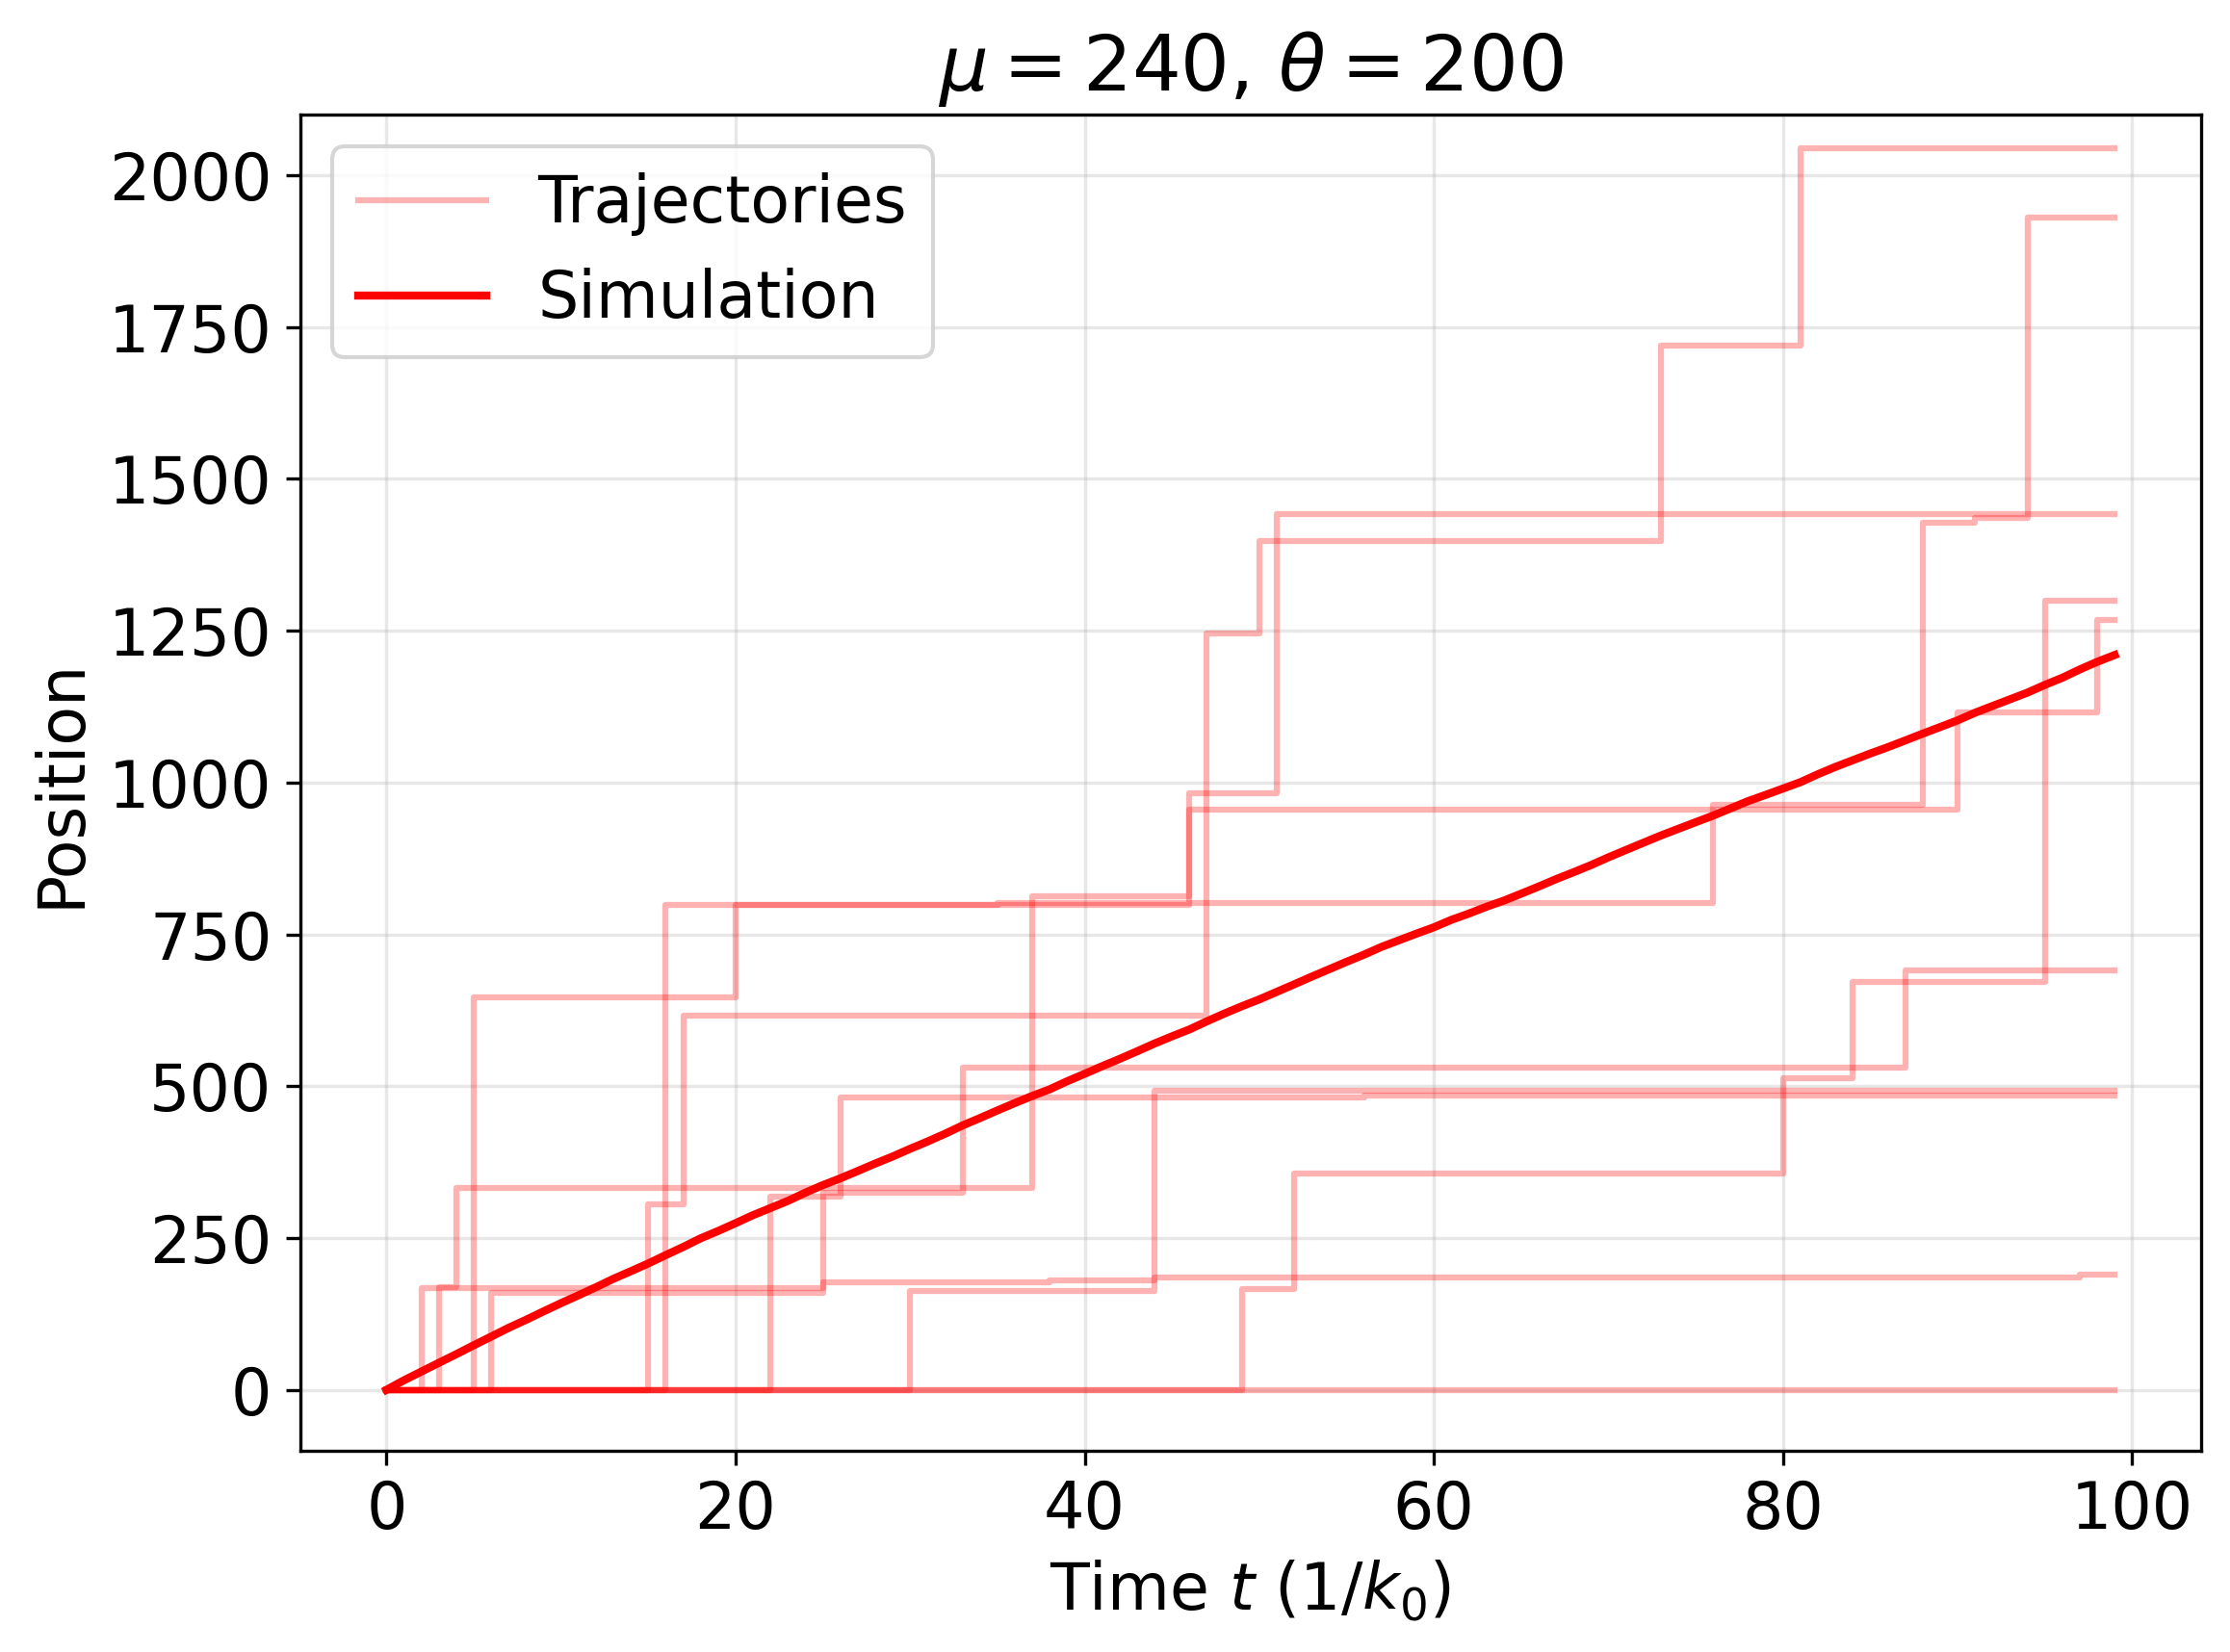

In [ ]:
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Options
# --------------------------------------------------
fit = False
n_fit_init = 5
n_fit_final = 5

# --------------------------------------------------
# Load files
# --------------------------------------------------
root = Path(
    "/home/nicolas/Documents/Workspace/nucleo/outputs/FIGURES__PC__2026-06-18/nucleo__fig3__0"
)

paths = (
    sorted(str(p) for p in root.glob("*/**/*.parquet"))
    or sorted(str(p) for p in root.glob("*/*.parquet"))
)

df_all = (
    pl.scan_parquet(paths)
    .collect()
    .sort(
        by=[
            "algo",
            "fact",
            "mode",
            "land",
            "s",
            "l",
            "alphac",
            "alphar",
        ]
    )
)

df_one = df_all.filter(pl.col("land") == "random")

# --------------------------------------------------
# Couples (mu, theta)
# --------------------------------------------------
pairs = (
    df_one.select(["mu", "theta"])
    .unique()
    .sort(["mu", "theta"])
    .to_numpy()
)

# --------------------------------------------------
# Loop
# --------------------------------------------------
for mu_val, theta_val in pairs:

    df_theta = df_one.filter(
        (pl.col("mu") == mu_val)
        & (pl.col("theta") == theta_val)
    )

    if df_theta.height == 0:
        continue

    # --------------------------------------------------
    # Extraction
    # --------------------------------------------------
    trajs = df_theta["results"][0]
    mean_traj = np.asarray(df_theta["results_mean"][0])
    times = np.asarray(df_theta["times"][0])

    v_mean_th = df_theta["v_mean_th"][0]
    mu = df_theta["mu"][0]

    # --------------------------------------------------
    # Figure
    # --------------------------------------------------
    plt.figure(figsize=(8, 6), dpi=300)

    # Trajectoires individuelles
    n_traj = min(10, len(trajs))

    for i in range(n_traj):
        plt.plot(
            trajs[i],
            drawstyle="steps-post",
            color="red",
            alpha=0.3,
            label="Trajectories" if i == 0 else None,
        )

    # Moyenne simulation
    plt.plot(
        times,
        mean_traj,
        color="red",
        lw=2,
        label="Simulation",
    )

    # --------------------------------------------------
    # Fits
    # --------------------------------------------------
    if fit:

        # ==========================================
        # Fit initial : x(t) = v_init * t
        # ==========================================
        if len(times) >= n_fit_init:

            t_init = times[:n_fit_init]
            x_init = mean_traj[:n_fit_init]

            mask = t_init > 0

            if np.sum(mask) >= 2:

                t_fit = t_init[mask]
                x_fit = x_init[mask]

                # Fit forcé passant par l'origine
                v_init = np.sum(t_fit * x_fit) / np.sum(t_fit**2)

                x_init_fit = v_init * t_fit

                plt.plot(
                    t_fit,
                    x_init_fit,
                    color="black",
                    ls = "--",
                    lw=2,
                    # label=rf"$v_{{\rm init}}={v_init:.3g}$",
                )

                idx_txt = len(t_fit) // 2

                x_offset = 0.025 * (plt.xlim()[1] - plt.xlim()[0])
                y_offset = 0.10 * (plt.ylim()[1] - plt.ylim()[0])

                plt.text(
                    t_fit[idx_txt] + x_offset,
                    x_init_fit[idx_txt] + y_offset,
                    rf"$x(t)=v_{{\rm init}}\,t$",
                    color="black",
                    fontsize=plt.rcParams["font.size"],
                    ha="center",
                )

        # ==========================================
        # Fit final : x(t) = C_f * t^{w_f}
        # ==========================================
        if len(times) >= n_fit_final:

            t_end = times[-n_fit_final:]
            x_end = mean_traj[-n_fit_final:]

            mask = (t_end > 0) & (x_end > 0)

            if np.sum(mask) >= 2:

                log_t = np.log(t_end[mask])
                log_x = np.log(x_end[mask])

                wf, log_Cf = np.polyfit(log_t, log_x, 1)
                Cf = np.exp(log_Cf)

                x_end_fit = Cf * t_end**wf

                plt.plot(
                    t_end,
                    x_end_fit,
                    color="black",
                    ls = "--",
                    lw=2,
                    # label=rf"$C_f={Cf:.3g},\,w_f={wf:.3g}$",
                )

                idx_txt = len(t_end) // 2

                x_offset = 0.05 * (plt.xlim()[1] - plt.xlim()[0])
                y_offset = 0.05 * (plt.ylim()[1] - plt.ylim()[0])

                plt.text(
                    t_end[idx_txt] - x_offset,
                    x_end_fit[idx_txt] + y_offset,
                    rf"$x(t)=C_f\,t^{{w_f}}$",
                    color="black",
                    fontsize=plt.rcParams["font.size"],
                    ha="center",
                )

    # --------------------------------------------------
    # Mise en forme
    # --------------------------------------------------
    plt.ylim([-100, 2100])

    plt.title(
        rf"$\mu={mu}$, $\theta={theta_val}$"
    )

    plt.xlabel(r"Time $t$ ($1/k_0$)")
    plt.ylabel("Position")

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.show()

In [5]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
plt.rcParams["font.size"] = 16

plt.figure(figsize=(8,6), dpi=1200)
thetas = np.unique(df_all["theta"].to_numpy())

def th_instantaneous_speeds(mu, theta, v, alpha0=10/160, k0=1):
    a = (mu / theta) ** 2
    b = mu / (theta ** 2)
    return (alpha0 * k0) * (a*b) * (v*b)**(a-1) / (alpha0*k0 + b*v)**(a+1)


cmap = cm.get_cmap("viridis")
n_colors = len(thetas)
color_positions = np.linspace(0.1, 0.4, n_colors)  # ajuste l’intervalle si besoin
color_list = [cmap(pos) for pos in color_positions]
color_list.reverse()


# v_mean (sans label)

MU = df_all["mu"].to_numpy()
l = df_all["l"].to_numpy()
s = df_all["s"].to_numpy()
alpha = l[0] / (l[0] + s[0])

# plt.axvline(
#     x=alpha * MU[0] / 2,
#     color="black",
#     ls=":",
#     lw=2,
#     alpha=1,
#     label="_nolegend_"
# )

for idx, theta_val in enumerate(thetas[0:3]):

    df_theta = df_all.filter(pl.col("theta") == theta_val)
    mu = df_theta["mu"][0]  # FIX: recalculé ici, ne plus dépendre de la cellule 2.A
    vi_points = df_theta["vi_points"][0].to_numpy()
    vi_distrib = df_theta["vi_distrib"][0].to_numpy()
    v_mean = df_theta["v_mean"].to_numpy()

    # =========================
    #  Ligne théorie v_init ~ alpha * (sigma k0)^-2
    # =========================

    alpha = 1  # ajuste si nécessaire pour que la courbe tombe au bon niveau
    init_points = vi_points[int(len(vi_points)/5000):]
    v_init = alpha * init_points**(-2)

    # plt.plot(
    #     init_points,
    #     v_init * 30,
    #     color="black",
    #     ls="dashdot",
    #     lw=2.5,
    #     label=r"$\propto v_{i}^{-2}$"
    # )

    # ax = plt.gca()

    # ax.text(
    #     0.98, 0.05,                         # (x,y) en coordonnées d'axe
    #     r"$\propto v^{-2}$",
    #     transform=ax.transAxes,
    #     fontsize=16,
    #     color="black",
    #     ha="right",
    #     va="bottom",
    #     rotation=-52
    # )

    # Simulation (avec label couleur)
    plt.plot(
        vi_points,
        vi_distrib,
        color=color_list[idx],
        ls="-",
        lw=2,
        alpha=0.70,
        label=f"(μ,θ)=({mu},{theta_val})"
    )

    # # Théorie (sans label)
    # plt.plot(
    #     vi_points,
    #     th_instantaneous_speeds(mu, theta_val, vi_points),
    #     color=color_list[idx],
    #     ls="--",
    #     lw=2,
    #     alpha=0.70,
    #     label="_nolegend_"
    # )


# =========================
#        LÉGENDES
# =========================

ax = plt.gca()

from matplotlib.lines import Line2D

# --- Lignes de style ---
style_legend = [
    # Line2D([0], [0], color="black", lw=2, ls="-", label="Simulation"),
    # Line2D([0], [0], color="black", lw=2, ls="--", label="Theory"),
    # Line2D([0], [0], color="black", lw=2, ls=":", label=r"$v_{hom}/2$")
]

# --- Lignes de couleur pour θ ---
theta_labels = [r"$\theta={}$".format(t) for t in thetas]
color_legend = [Line2D([0], [0], color=color_list[i], lw=2, label=theta_labels[i]) 
                for i in range(len(thetas))]

# --- Combiner les deux ---
all_legend = style_legend + color_legend

# --- Ajouter la légende verticale ---
ax.legend(handles=all_legend, loc="upper right", frameon=True)  # pas de ncol = vertical


plt.xlabel(r'Velocity $v$ ($\sigma k_0$)')
plt.ylabel("Distribution")
plt.xlim([5e-1, 1e3])
plt.ylim([1e-4, 1e0])
plt.xscale("log")
plt.yscale("log")
plt.grid(True, alpha=0.3, which="both")

plt.show()

print(vi_points)

/tmp/ipykernel_35482/2630142624.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


[5.00000e-01 1.50000e+00 2.50000e+00 ... 9.99975e+04 9.99985e+04
 9.99995e+04]


In [5]:
# =========================
#        l_view plot
# =========================

plt.figure(figsize=(8,6), dpi=1200)

thetas = np.unique(df_all["theta"].to_numpy())
cmap = cm.get_cmap("viridis")
n_colors = len(thetas)
color_positions = np.linspace(0.1, 0.4, n_colors)
color_list = [cmap(pos) for pos in color_positions]
color_list.reverse()

for idx, theta_val in enumerate(thetas):

    df_theta = df_all.filter(pl.col("theta") == theta_val)

    # récupère l_view (adaptation selon ton format)
    l_view = df_theta["l_view"][0]

    # axe x : si tu as un axe associé, remplace ici
    x = np.arange(len(l_view))

    plt.plot(
        x,
        l_view,
        color=color_list[idx],
        lw=2,
        alpha=0.8
    )

# =========================
#        LÉGENDES
# =========================

ax = plt.gca()
# ax.legend(loc="upper right", frameon=True)

plt.xlabel("Position")
plt.ylabel(r"$l_{view}$")
# plt.yscale("log")  # enlève si inutile
plt.grid(True, alpha=0.3, which="both")

plt.show()

/tmp/ipykernel_8607/1742893675.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


In [6]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import matplotlib.pyplot as plt

# =========================
#       l_view plot
# =========================

plt.figure(figsize=(8, 6), dpi=1200)
ax = plt.gca()
color = "orange"

# Choix du theta à afficher
theta_val = np.unique(df_all["theta"].to_numpy())[0]  # ou une valeur précise

df_theta = df_all.filter(pl.col("theta") == theta_val)

l_view = df_theta["l_view"][0]
x = np.arange(len(l_view))

# Tracé principal
ax.plot(
    x,
    l_view,
    lw=2,
    alpha=0.9,
    label=rf"$\theta={theta_val}$",
    c=color
)

# =========================
#         INSET
# =========================

axins = inset_axes(ax, width="60%", height="60%", loc="upper right")

n_zoom = min(750, len(l_view))

axins.plot(
    x[:n_zoom],
    l_view[:n_zoom],
    lw=1.5,
    c=color
)

axins.set_xlim(0, n_zoom)
axins.grid(True, alpha=0.3)

# Facultatif : alléger les ticks
axins.tick_params(axis='both', labelsize=7)

# =========================
#        LÉGENDES
# =========================

ax.set_xlabel("Position")
ax.set_ylabel(r"$l_{view}$")
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

/tmp/ipykernel_35482/1736169360.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


# .